In [8]:
import pandas as pd

# 예시 데이터프레임 생성
data = {'customer_id': [1, 2, 3],
        'purchase1': [100, 200, 150],
        'purchase2': [80, 120, 130]}
df = pd.DataFrame(data)

df

,customer_id,purchase1,purchase2
0,1,100,80
1,2,200,120
2,3,150,130


In [9]:
df['total_purchase'] = df['purchase1'] + df['purchase2']

df

,customer_id,purchase1,purchase2,total_purchase
0,1,100,80,180
1,2,200,120,320
2,3,150,130,280


In [10]:
import pandas as pd

# 예시 데이터프레임 생성
data = {'region': ['A', 'A', 'B', 'B', 'C'],
        'income': [5000, 6000, 5500, 6200, 5800]}
df = pd.DataFrame(data)
df

,region,income
0,A,5000
1,A,6000
2,B,5500
3,B,6200
4,C,5800


In [11]:
avg_income = df.groupby('region')['income'].mean().reset_index()
avg_income

,region,income
0,A,5500.0
1,B,5850.0
2,C,5800.0


In [12]:
avg_income.rename(columns= {'income': "avg_income"}, inplace=True)

avg_income

,region,avg_income
0,A,5500.0
1,B,5850.0
2,C,5800.0


In [13]:
avg_income = df.groupby('region')['income'].transform('mean')
avg_income

0    5500.0
1    5500.0
2    5850.0
3    5850.0
4    5800.0
Name: income, dtype: float64

In [14]:
df['avg_income'] = avg_income
df

,region,income,avg_income
0,A,5000,5500.0
1,A,6000,5500.0
2,B,5500,5850.0
3,B,6200,5850.0
4,C,5800,5800.0


In [15]:
#transform() : 매개변수의 기준에 따라 계산하여 원래 행의 개수만큼 반환
avg_income = df.groupby('region')['income'].transform('mean')
avg_income

0    5500.0
1    5500.0
2    5850.0
3    5850.0
4    5800.0
Name: income, dtype: float64

In [16]:
df['region_avg_income'] = avg_income
df

,region,income,avg_income,region_avg_income
0,A,5000,5500.0,5500.0
1,A,6000,5500.0,5500.0
2,B,5500,5850.0,5850.0
3,B,6200,5850.0,5850.0
4,C,5800,5800.0,5800.0


In [17]:
import pandas as pd

# 예시 데이터프레임 생성
data = {'person': ['X', 'Y', 'Z'],
        'income': [4000, 5000, 6000]}
df = pd.DataFrame(data)

df

,person,income
0,X,4000
1,Y,5000
2,Z,6000


In [18]:
mean_income = df['income'].mean()
mean_income

np.float64(5000.0)

In [19]:
df['income_diff'] = df['income'] - mean_income
df

,person,income,income_diff
0,X,4000,-1000.0
1,Y,5000,0.0
2,Z,6000,1000.0


In [20]:
import pandas as pd

# 예시 데이터프레임 생성
data = {'region': ['A', 'B', 'C', 'D'],
        'avg_income': [5500, 5000, 6000, 4500]}
df = pd.DataFrame(data)

# 기준점 설정 (전체 평균 소득)
mean_income = df['avg_income'].mean()

# 소득 수준 분류
def categorize_income(x):
    if x > mean_income:
        return '높음'
    elif x == mean_income:
        return '보통'
    else:
        return '낮음'

df['income_level'] = df['avg_income'].apply(categorize_income)
print(df)
    

  region  avg_income income_level
0      A        5500           높음
1      B        5000           낮음
2      C        6000           높음
3      D        4500           낮음


In [21]:
import pandas as pd
import numpy as np

# 예시 데이터프레임 생성
data = {'name': ['Alice', 'Bob', 'Charlie', 'David'],
        'age': [25, np.nan, 30, np.nan]}
df = pd.DataFrame(data)

df

,name,age
0,Alice,25.0
1,Bob,NaN
2,Charlie,30.0
3,David,NaN


In [22]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4 entries, 0 to 3
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   name    4 non-null      str    
 1   age     2 non-null      float64
dtypes: float64(1), str(1)
memory usage: 196.0 bytes


In [23]:
mean_age = df['age'].mean()
mean_age

np.float64(27.5)

In [24]:
df = df['age'].fillna(mean_age)
df

0    25.0
1    27.5
2    30.0
3    27.5
Name: age, dtype: float64

In [25]:
import pandas as pd
import numpy as np

# 예시 데이터프레임 생성
data = {'name': ['Alice', 'Bob', 'Charlie', 'David'],
        'age': [25, np.nan, 30, np.nan]}
df = pd.DataFrame(data)
df

,name,age
0,Alice,25.0
1,Bob,NaN
2,Charlie,30.0
3,David,NaN


In [26]:
import pandas as pd
import numpy as np

# 예시 데이터프레임 생성
data = {'name': ['Alice', 'Bob', 'Charlie', 'David'],
        'age': [25, np.nan, 30, np.nan]}
df = pd.DataFrame(data)

# 평균 나이 계산
mean_age = df['age'].mean()

# 결측값 대체
df['age'] = df['age'].fillna(mean_age)
print(df)

      name   age
0    Alice  25.0
1      Bob  27.5
2  Charlie  30.0
3    David  27.5


In [27]:
# 예시 데이터프레임 생성
data = {'student': ['A', 'B', 'C', 'D', 'E'],
        'score': [80, np.nan, 90, np.nan, 85]}
df = pd.DataFrame(data)

In [28]:

# 결측값 위치 확인
nan_indices = df[df['score'].isnull()].index
nan_indices

RangeIndex(start=1, stop=5, step=2)

In [29]:
df['score'].dropna()

0    80.0
2    90.0
4    85.0
Name: score, dtype: float64

In [30]:
len(nan_indices)

2

In [31]:
np.random.seed(0) # 시드 고정 : 재현성 확보

In [32]:

# 무작위 대체
df.loc[nan_indices, 'score'] = np.random.choice(df['score'].dropna())
df

,student,score
0,A,80.0
1,B,80.0
2,C,90.0
3,D,80.0
4,E,85.0


In [33]:
%pip install scikit-learn

Note: you may need to restart the kernel to use updated packages.


In [34]:
import pandas as pd
from sklearn.experimental import enable_iterative_imputer #imputer는 작은 인공지능 모델이다.
from sklearn.impute import IterativeImputer

# 예시 데이터프레임 생성
data = {'feature1': [1.0, 2.1, np.nan, 4.3, 5.2],
        'feature2': [3.2, np.nan, 1.8, 2.5, 4.0]}
df = pd.DataFrame(data)
df

,feature1,feature2
0,1.0,3.2
1,2.1,NaN
2,NaN,1.8
3,4.3,2.5
4,5.2,4.0


In [35]:
df.columns

Index(['feature1', 'feature2'], dtype='str')

In [36]:
#다중대치법
#IterativeImputer : 반복값 결측값 대체 모델(10번 반복, 시드 고정)

imputer = IterativeImputer(max_iter = 10, random_state = 0)
df_imputed = pd.DataFrame(imputer.fit_transform(df), columns = df.columns)
df_imputed

,feature1,feature2
0,1.000000,3.200000
1,2.100000,2.874009
2,3.148439,1.800000
3,4.300000,2.500000
4,5.200000,4.000000


In [37]:
import pandas as pd

# 예시 데이터프레임 생성
data = {'value': [10, 12, 14, 16, 18, 100]}
df = pd.DataFrame(data)
df

,value
0,10
1,12
2,14
3,16
4,18
5,100


In [38]:
# 사분위수 계산
Q1 = df['value'].quantile(0.25)
Q3 = df['value'].quantile(0.75)
IQR = Q3 - Q1
print(Q1,Q3,IQR)

12.5 17.5 5.0


In [39]:
# 이상값 기준 계산
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

In [40]:

# 이상값 식별
outliers = df[(df['value'] < lower_bound) | (df['value'] > upper_bound)]
print(outliers)

   value
5    100


In [41]:
import pandas as pd
import matplotlib.pyplot as plt

# 예시 데이터프레임 생성
data = {'value': [10, 12, 14, 16, 18, 100]}
df = pd.DataFrame(data)


In [42]:
df

,value
0,10
1,12
2,14
3,16
4,18
5,100


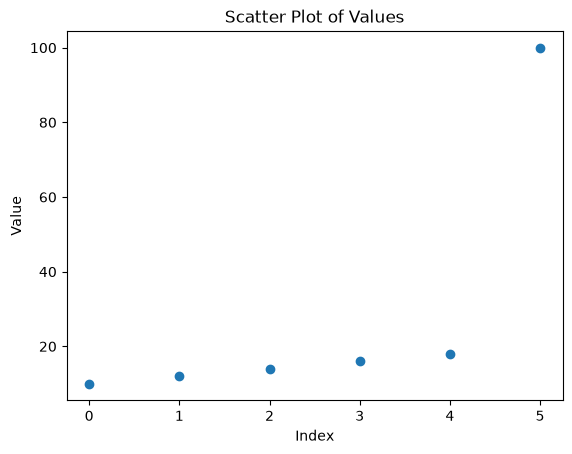

In [43]:
# 산점도 그리기
plt.scatter(df.index, df['value'])
plt.title('Scatter Plot of Values')
plt.xlabel('Index')
plt.ylabel('Value')
plt.show()

In [44]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
# 예시 데이터프레임 생성
data = {'score': [70, 80, 90, 100, 110]}
df = pd.DataFrame(data)

# 평균과 표준편차 계산
mean = df['score'].mean()
std = df['score'].std()

# Z-변환 적용
df['z_score'] = (df['score'] - mean) / std
print(df)

   score   z_score
0     70 -1.264911
1     80 -0.632456
2     90  0.000000
3    100  0.632456
4    110  1.264911


In [45]:
import pandas as pd

# 예시 데이터프레임 생성
data = {'score': [70, 80, 90, 100, 110]}
df = pd.DataFrame(data)

# 최소값과 최대값 계산
min_val = df['score'].min()
max_val = df['score'].max()

# [0-1] 변환 적용
df['normalized_score'] = (df['score'] - min_val) / (max_val - min_val)
print(df)

   score  normalized_score
0     70              0.00
1     80              0.25
2     90              0.50
3    100              0.75
4    110              1.00


In [46]:
# 예시 데이터프레임 생성
data = {'score': [70, 80, 90, 100, 110]}
df = pd.DataFrame(data)
df

,score
0,70
1,80
2,90
3,100
4,110


In [49]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()

df["normalized_score"] = scaler.fit_transform(df[["score"]])

df

,score,normalized_score
0,70,0.00
1,80,0.25
2,90,0.50
3,100,0.75
4,110,1.00


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

n = 30
trials = 10000

sample_means = []

for _ in range(trials):
    # 1 ~ 6까지의 숫자를 랜덤으로 n(30)개 뽑음 (결과:리스트)
    samples = np.random.randint(1,7,n)
    #결과 리스트 평균치를 하나의 요소로 더함
    sample_means.append(np.mean(samples))

sample_means    

[np.float64(3.3),
 np.float64(3.2),
 np.float64(3.7666666666666666),
 np.float64(3.2333333333333334),
 np.float64(3.1333333333333333),
 np.float64(3.533333333333333),
 np.float64(3.2666666666666666),
 np.float64(3.9),
 np.float64(3.6),
 np.float64(3.5),
 np.float64(3.5),
 np.float64(3.3333333333333335),
 np.float64(3.966666666666667),
 np.float64(3.033333333333333),
 np.float64(3.3),
 np.float64(3.466666666666667),
 np.float64(3.5),
 np.float64(3.6),
 np.float64(3.6333333333333333),
 np.float64(3.7666666666666666),
 np.float64(3.2333333333333334),
 np.float64(4.133333333333334),
 np.float64(3.8),
 np.float64(3.1),
 np.float64(3.6666666666666665),
 np.float64(3.1),
 np.float64(3.566666666666667),
 np.float64(4.0),
 np.float64(3.7666666666666666),
 np.float64(3.3666666666666667),
 np.float64(4.033333333333333),
 np.float64(3.466666666666667),
 np.float64(3.066666666666667),
 np.float64(3.8666666666666667),
 np.float64(3.4),
 np.float64(4.0),
 np.float64(3.533333333333333),
 np.float64(3.

(array([4.93150685e-03, 7.39726027e-03, 2.46575342e-02, 3.82191781e-02,
        8.38356164e-02, 1.18356164e-01, 3.13150685e-01, 2.86027397e-01,
        4.47534247e-01, 9.03698630e-01, 7.40958904e-01, 1.35369863e+00,
        9.48082192e-01, 1.60397260e+00, 9.61643836e-01, 9.34520548e-01,
        1.23534247e+00, 6.55890411e-01, 7.17534247e-01, 3.24246575e-01,
        3.19315068e-01, 1.17123288e-01, 8.50684932e-02, 5.79452055e-02,
        2.58904110e-02, 1.60273973e-02, 1.23287671e-03, 1.23287671e-03,
        0.00000000e+00, 1.23287671e-03]),
 array([2.4       , 2.48111111, 2.56222222, 2.64333333, 2.72444444,
        2.80555556, 2.88666667, 2.96777778, 3.04888889, 3.13      ,
        3.21111111, 3.29222222, 3.37333333, 3.45444444, 3.53555556,
        3.61666667, 3.69777778, 3.77888889, 3.86      , 3.94111111,
        4.02222222, 4.10333333, 4.18444444, 4.26555556, 4.34666667,
        4.42777778, 4.50888889, 4.59      , 4.67111111, 4.75222222,
        4.83333333]),
 <BarContainer object of

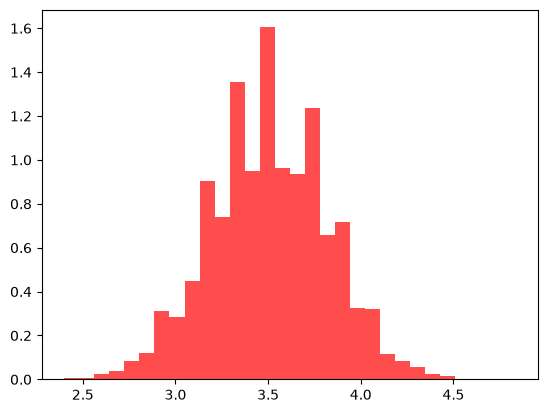

In [51]:
plt.hist(sample_means,
         bins = 30,
         density = True, 
         alpha = 0.7, 
         color = 'red')

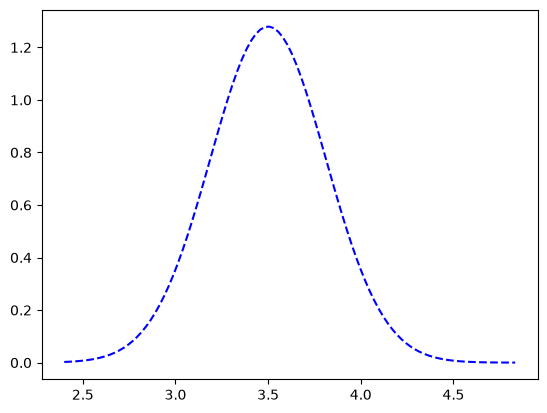

In [52]:
from scipy.stats import norm
mu = 3.5
sigma = np.sqrt(35/12) / np.sqrt(n)
x = np.linspace(min(sample_means), max(sample_means), 100)
plt.plot(x, norm.pdf(x, mu, sigma), 'b--')